Instalando a biblioteca neurokit2 para análise de ECGs

In [18]:
%pip install neurokit2
%pip install seaborn


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Importando as bibliotecas necessárias

In [19]:
import pandas as pd
import io
import os
import neurokit2 as nk
from datetime import datetime
import sklearn
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

Carregando a tabela BancoChagas-Geral-Padronizado-25-09-2023.xlsx

In [20]:

caminho_do_arquivo = '/home/leo-vitor/Documentos/UFC/biosinais/dataset-pesquisa-ecg/BancoChagas-Geral-Padronizado-25-09-2023.xlsx'
tabela = pd.read_excel(caminho_do_arquivo)



In [21]:
print(tabela.columns)

Index(['Paciente', 'Nome do Paciente', 'filename', 'Prontuario', 'Date Nasc',
       'Data Holter', 'Sexo', 'Nat', 'BMI ', 'Cancer', 'AVC', 'DLP', 'HAS',
       'DM2', 'Cardiopatia Outra', 'Marcapasso', 'Sincope',
       'Fibrilação/Flutter Atrial', 'I R Crônica', 'Coronariopatia',
       'Embolia Pulmonar', 'Ins Cardiaca ', 'AVC.1', 'DVP', 'TSH', 'Tabagismo',
       'Alcoolismo', 'Sedentarismo', 'ECG ', 'FC', 'Alt Prim',
       'Dist Cond InterVent ', 'Dist Cond AtrioVent ', 'Pausa > 3s ', 'ESV',
       'EV', 'TVMNS', 'Area Elet inativa', 'Holter', 'Dist Cond AtrioVent.1',
       'Disf Nodulo Sinusal', 'Fibri/Flutter Atrial', 'FC media', 'TVS',
       'TVMNS.1', 'EV.1', 'EVTotal', 'ECO', 'AE diam.', 'VED', 'VES',
       'FE Teicholz', 'Classificação', 'Disf Diastolica', 'Deficit Seg',
       'NYHA', 'Rassi pontos', 'Rassi escore', 'Diretriz 2005', 'CDI ',
       'Ablações', 'Amiodarona', 'Obito', 'Obito_MS', 'TendQ - 5º Percentil',
       'TpeakQ - 5º Percentil', '% - Qtend/TendQ > 1'

# Tratamento de dados da tabela
---


Verificando a quantidade de valores nulos por coluna

In [22]:
# Verificando a quantidade de valores nulos em cada coluna
valores_nulos_por_coluna = tabela.isnull().sum()

# Obtendo o número total de linhas
total_linhas = len(tabela)

# Exibindo os resultados
print("Quantidade de valores nulos por coluna:")
print(valores_nulos_por_coluna)

print("\nTotal de linhas no conjunto de dados:", total_linhas)


Quantidade de valores nulos por coluna:
Paciente                     555
Nome do Paciente               1
filename                     180
Prontuario                     8
Date Nasc                      2
Data Holter                    2
Sexo                           2
Nat                            2
BMI                            2
Cancer                         2
AVC                            2
DLP                            2
HAS                            2
DM2                            2
Cardiopatia Outra              2
Marcapasso                     2
Sincope                        2
Fibrilação/Flutter Atrial      2
I R Crônica                    2
Coronariopatia                 8
Embolia Pulmonar               2
Ins Cardiaca                   2
AVC.1                          2
DVP                            2
TSH                            3
Tabagismo                      2
Alcoolismo                     2
Sedentarismo                   2
ECG                            2
FC 

Removendo as colunas onde o valor da coluna 'filename' é nulo

In [23]:
# Remover linhas onde 'filename' é nulo
tabela = tabela.dropna(subset=['filename'])

# Verificar novamente a quantidade de valores nulos em cada coluna
valores_nulos_por_coluna = tabela.isnull().sum()

# Exibir os resultados
print("Quantidade de valores nulos por coluna após remoção de linhas nulas em 'filename':")
print(valores_nulos_por_coluna)

Quantidade de valores nulos por coluna após remoção de linhas nulas em 'filename':
Paciente                     375
Nome do Paciente               0
filename                       0
Prontuario                     4
Date Nasc                      0
Data Holter                    0
Sexo                           0
Nat                            0
BMI                            0
Cancer                         0
AVC                            0
DLP                            0
HAS                            0
DM2                            0
Cardiopatia Outra              0
Marcapasso                     0
Sincope                        0
Fibrilação/Flutter Atrial      0
I R Crônica                    0
Coronariopatia                 4
Embolia Pulmonar               0
Ins Cardiaca                   0
AVC.1                          0
DVP                            0
TSH                            0
Tabagismo                      0
Alcoolismo                     0
Sedentarismo              

Removendo colunas que não são interessantes para a análise

In [7]:
# Excluindo as colunas da tabela
colunas_excluir = ["Nome do Paciente", "filename", "Prontuario","Observações","Paciente"]
tabela = tabela.drop(columns=colunas_excluir)

Separando os dados da tabela em categóricos e numéricos:

**Variáveis Categóricas:**

- Nome do Paciente
- filename
- Prontuario
- Sexo (Masc=1 Fem=0)
- Nat (Sigla do Estado)
- Cancer (Não=0 Sim=1)
- AVC (Não=0 Sim=1)
- DLP (Não=0 Sim=1)
- HAS (Não=0 Sim=1)
- DM2 (Não=0 Sim=1)
- Cardiopatia Outra (Não=0 Sim=1)
- Marcapasso (Não=0 Sim=1)
- Sincope (Não=0 Sim=1)
- Fibrilação/Flutter Atrial (Não=0 Sim=1)
- I R Crônica (Não=0 Sim=1)
- Coronariopatia (Não=0 Sim=1)
- Embolia Pulmonar (Não=0 Sim=1)
- Ins Cardiaca (Não=0 Sim=1)
- DVP (Não=0 Sim=1)
- Tabagismo (Não=0 Sim=1)
- Alcoolismo (Não=0 Sim=1)
- Sedentarismo (Não=0 Sim=1)
- ECG (Não fez o exame=0 Fez o exame=1)
- Alt Prim (Não=0 Sim=1)
- Dist Cond InterVent (Não=0 Sim=1 BRE=2 BRD+HBAE=3)
- Dist Cond AtrioVent (Não=0 Sim=1 BRE=2 BRD+HBAE=3)
- Pausa > 3s (Não=0 Sim=1)
- ESV (Não=0 Sim=1)
- EV (Não=0 Sim=1)
- TVMNS (Não=0 Sim=1)
- Area Elet inativa (Não=0 Sim=1)
- Holter (Não=0 Sim=1)
- Dist Cond AtrioVent.1 (Não=0 Sim=1)
- Disf Nodulo Sinusal (Não=0 Sim=1)
- Fibri/Flutter Atrial (Não=0 Sim=1)
- TVS (Não=0 Sim=1)
- TVMNS.1 (Não=0 Sim=1)
- EV.1 (Não=0 Sim=1)
- ECO (Não=0 Sim=1)
- Disf Diastolica (1 = alteração de distensibilidade padrão e < A 2 = padrão pseudo-normal que já pode apresentar sinais de pressão de enchimento elevada 3 = padrão restritivo pela manobra de Valsalva ou diminuição da pré-carga é reversível 4 = padrão restritivo pela manobra de Valsalva ou diminuição da pré-carga é irreversível)
- Deficit Seg (Não=0 Sim=1)
- NYHA (1 = Disp alem das atividades habitais 2 = Disp aquem das atividades habitais 3 = Disp no repouso 4 = Edema agudo de Pulmão)
- Rassi Pontos (Masc= 2 Baixa Voltagem= 2 TVMNS= 3 Disf global ou Seg= 3 Cardiomegalia= 5 ICC III/IV = 5)
- Rassi escore (Baixo= 0 a 6 Intermediario 7 a 11 Alto= 12 a 20)
- Diretriz 2005 (A=ECG alterado B1=ECG alt+ECO alt e FE>45% B2=ECG alt+ECO alt e FE<45% C=Insuf Cardiaca Compensada D=Insuf Cardiaca Refrataria)
- CDI (Não=0 Sim=1)
- Ablações (Não=0 Sim=1)
- Amiodarona (Não=0 Sim=1)
- Obito (Não=0 Sim=1)
- Obito_MS (Não=0 Sim=1)

**Notas:**
- A coluna "Disf Diastolica" é categorizada de acordo com os diferentes padrões de disfunção diastólica.
- A coluna "Rassi Pontos" parece ter categorias específicas associadas a diferentes valores.
- A coluna "Rassi escore" parece ter categorias baseadas em faixas de pontuação.
- A coluna "Diretriz 2005" possui categorias específicas associadas

Fazendo encoding de variaveis categóricas ordinais




In [25]:
print(tabela.columns)

Index(['Nome do Paciente', 'filename', 'Prontuario', 'Date Nasc',
       'Data Holter', 'Sexo', 'Nat', 'BMI ', 'Cancer', 'AVC', 'DLP', 'HAS',
       'DM2', 'Cardiopatia Outra', 'Marcapasso', 'Sincope',
       'Fibrilação/Flutter Atrial', 'I R Crônica', 'Coronariopatia',
       'Embolia Pulmonar', 'Ins Cardiaca ', 'AVC.1', 'DVP', 'TSH', 'Tabagismo',
       'Alcoolismo', 'Sedentarismo', 'ECG ', 'FC', 'Alt Prim',
       'Dist Cond InterVent ', 'Dist Cond AtrioVent ', 'Pausa > 3s ', 'ESV',
       'EV', 'TVMNS', 'Area Elet inativa', 'Holter', 'Dist Cond AtrioVent.1',
       'Disf Nodulo Sinusal', 'Fibri/Flutter Atrial', 'FC media', 'TVS',
       'TVMNS.1', 'EV.1', 'EVTotal', 'ECO', 'AE diam.', 'VED', 'VES',
       'FE Teicholz', 'Classificação', 'Disf Diastolica', 'Deficit Seg',
       'NYHA', 'Rassi pontos', 'Rassi escore', 'Diretriz 2005', 'CDI ',
       'Ablações', 'Amiodarona', 'Obito', 'Obito_MS', 'TendQ - 5º Percentil',
       'TpeakQ - 5º Percentil', '% - Qtend/TendQ > 1', '% - QTpea

In [26]:
# Exibir informações sobre o DataFrame, incluindo o número de valores não nulos em cada coluna
tabela.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 375 entries, 0 to 551
Data columns (total 70 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Nome do Paciente           375 non-null    object        
 1   filename                   375 non-null    float64       
 2   Prontuario                 371 non-null    float64       
 3   Date Nasc                  375 non-null    datetime64[ns]
 4   Data Holter                375 non-null    object        
 5   Sexo                       375 non-null    float64       
 6   Nat                        375 non-null    object        
 7   BMI                        375 non-null    float64       
 8   Cancer                     375 non-null    float64       
 9   AVC                        375 non-null    float64       
 10  DLP                        375 non-null    float64       
 11  HAS                        375 non-null    float64       
 12  DM2     

Realizando o encoding das variáveis categóricas ordinais.

In [27]:
from sklearn.impute import SimpleImputer

# Lista de colunas ordinais
colunas_ordinais = ['Dist Cond InterVent ','Dist Cond AtrioVent ','Disf Diastolica','NYHA','Rassi pontos','Rassi escore','Diretriz 2005']

# Inicializar o SimpleImputer com estratégia 'most_frequent' para moda
imputador_moda = SimpleImputer(strategy='most_frequent')

# Tratar valores nulos nas colunas ordinais
for coluna in colunas_ordinais:
    if coluna in tabela.columns:
        tabela[coluna].fillna(tabela[coluna].mode()[0], inplace=True)  # Preencher com a moda

# Exibir a tabela apóos o tratamento de dados faltantes
print(tabela[colunas_ordinais])


     Dist Cond InterVent   Dist Cond AtrioVent   Disf Diastolica  NYHA  \
0                     3.0                   0.0              1.0   1.0   
1                     3.0                   0.0              1.0   1.0   
2                     3.0                   0.0              1.0   1.0   
3                     3.0                   0.0              1.0   1.0   
4                     3.0                   0.0              1.0   1.0   
5                     3.0                   0.0              1.0   1.0   
6                     3.0                   0.0              1.0   2.0   
7                     3.0                   0.0              1.0   2.0   
8                     3.0                   0.0              1.0   2.0   
9                     3.0                   0.0              1.0   2.0   
10                    3.0                   0.0              0.0   1.0   
11                    3.0                   0.0              0.0   1.0   
12                    3.0             

Realizando o label encoding dessas colunas

In [28]:
from sklearn.preprocessing import LabelEncoder

# Criar um objeto LabelEncoder
label_encoder = LabelEncoder()

# Aplicar o Label Encoding para cada coluna ordinal
for coluna in colunas_ordinais:
    tabela[coluna + '_encoded'] = label_encoder.fit_transform(tabela[coluna])

# Exibir a tabela com as novas colunas codificadas
print(tabela[colunas_ordinais + [coluna + '_encoded' for coluna in colunas_ordinais]])

# Excluindo colunas originais
tabela = tabela.drop(colunas_ordinais, axis=1)


     Dist Cond InterVent   Dist Cond AtrioVent   Disf Diastolica  NYHA  \
0                     3.0                   0.0              1.0   1.0   
1                     3.0                   0.0              1.0   1.0   
2                     3.0                   0.0              1.0   1.0   
3                     3.0                   0.0              1.0   1.0   
4                     3.0                   0.0              1.0   1.0   
5                     3.0                   0.0              1.0   1.0   
6                     3.0                   0.0              1.0   2.0   
7                     3.0                   0.0              1.0   2.0   
8                     3.0                   0.0              1.0   2.0   
9                     3.0                   0.0              1.0   2.0   
10                    3.0                   0.0              0.0   1.0   
11                    3.0                   0.0              0.0   1.0   
12                    3.0             

Agora faremos o tratamento das colunas categóricas nominais: "Nat"

In [29]:
# Criar lista de estados únicos
estados_unicos = tabela['Nat'].unique()

# Adicionar colunas para cada estado
for estado in estados_unicos:
    tabela[estado] = tabela['Nat'].apply(lambda x: 1 if x == estado else 0)

# Excluir a coluna original "Nat"
tabela.drop('Nat', axis=1, inplace=True)

# Exibir a tabela após o One-Hot Encoding da coluna "Nat"
print(tabela.head())


       Nome do Paciente  filename  Prontuario  Date Nasc          Data Holter  \
0  Adão Severo de Souza       1.0    333104.0 1950-11-29  2010-07-08 00:00:00   
1  Adão Severo de Souza       2.0    333104.0 1950-11-29  2010-01-14 00:00:00   
2  Adão Severo de Souza       3.0    333104.0 1950-11-29  2009-05-27 00:00:00   
3  Adão Severo de Souza       6.0    333104.0 1950-11-29  1997-11-03 00:00:00   
4  Adão Severo de Souza       5.0    333104.0 1950-11-29  2013-05-21 00:00:00   

   Sexo  BMI   Cancer  AVC  DLP  HAS  DM2  Cardiopatia Outra  Marcapasso  \
0   1.0  25.0     0.0  0.0  0.0  1.0  1.0                0.0         0.0   
1   1.0  23.0     0.0  0.0  0.0  1.0  1.0                0.0         0.0   
2   1.0  24.0     0.0  0.0  0.0  1.0  1.0                0.0         0.0   
3   1.0  26.0     0.0  0.0  0.0  1.0  1.0                0.0         0.0   
4   1.0  25.0     0.0  0.0  0.0  1.0  1.0                0.0         0.0   

   Sincope  Fibrilação/Flutter Atrial  I R Crônica  Coro

Agora, vamos transformar as colunas Date Nasc e Data Holter em Idade do Paciente e Tempo desde o ultimo exame em meses

In [30]:
# Convertendo a coluna 'Data Holter' para datetime
tabela['Data Holter'] = pd.to_datetime(tabela['Data Holter'], errors='coerce')

# Criando a coluna que representa o tempo desde o último exame em meses
tabela['Tempo desde último exame (meses)'] = (datetime.now() - tabela['Data Holter']).astype('<m8[M]')

# Criando a coluna que indica a idade do paciente em anos
tabela['Idade (anos)'] = (datetime.now() - tabela['Date Nasc']).astype('<m8[Y]')

# Deletando as colunas originais
tabela = tabela.drop(['Data Holter', 'Date Nasc'], axis=1)

In [16]:
print(tabela.head())

       Nome do Paciente  filename  Prontuario  Sexo  BMI   Cancer  AVC  DLP  \
0  Adão Severo de Souza       1.0    333104.0   1.0  25.0     0.0  0.0  0.0   
1  Adão Severo de Souza       2.0    333104.0   1.0  23.0     0.0  0.0  0.0   
2  Adão Severo de Souza       3.0    333104.0   1.0  24.0     0.0  0.0  0.0   
3  Adão Severo de Souza       6.0    333104.0   1.0  26.0     0.0  0.0  0.0   
4  Adão Severo de Souza       5.0    333104.0   1.0  25.0     0.0  0.0  0.0   

   HAS  DM2  Cardiopatia Outra  Marcapasso  Sincope  \
0  1.0  1.0                0.0         0.0      0.0   
1  1.0  1.0                0.0         0.0      0.0   
2  1.0  1.0                0.0         0.0      0.0   
3  1.0  1.0                0.0         0.0      0.0   
4  1.0  1.0                0.0         0.0      0.0   

   Fibrilação/Flutter Atrial  I R Crônica  Coronariopatia  Embolia Pulmonar  \
0                        0.0          0.0             0.0               0.0   
1                        0.0        

In [17]:
# Removendo a coluna 'Classificacao'
tabela = tabela.drop('Classificação', axis=1)

Agora vamos salvar essa tabela tratada para usa-la na criação de modelos

In [25]:
tabela_análise= tabela
tabela_análise.to_excel('/home/leo-vitor/Documentos/UFC/biosinais/dataset-pesquisa-ecg/tabela_análise.xlsx',index = False)

Imprimindo a matriz de correlação

/tmp/ipykernel_7473/1126707413.py:5: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = tabela.corr()


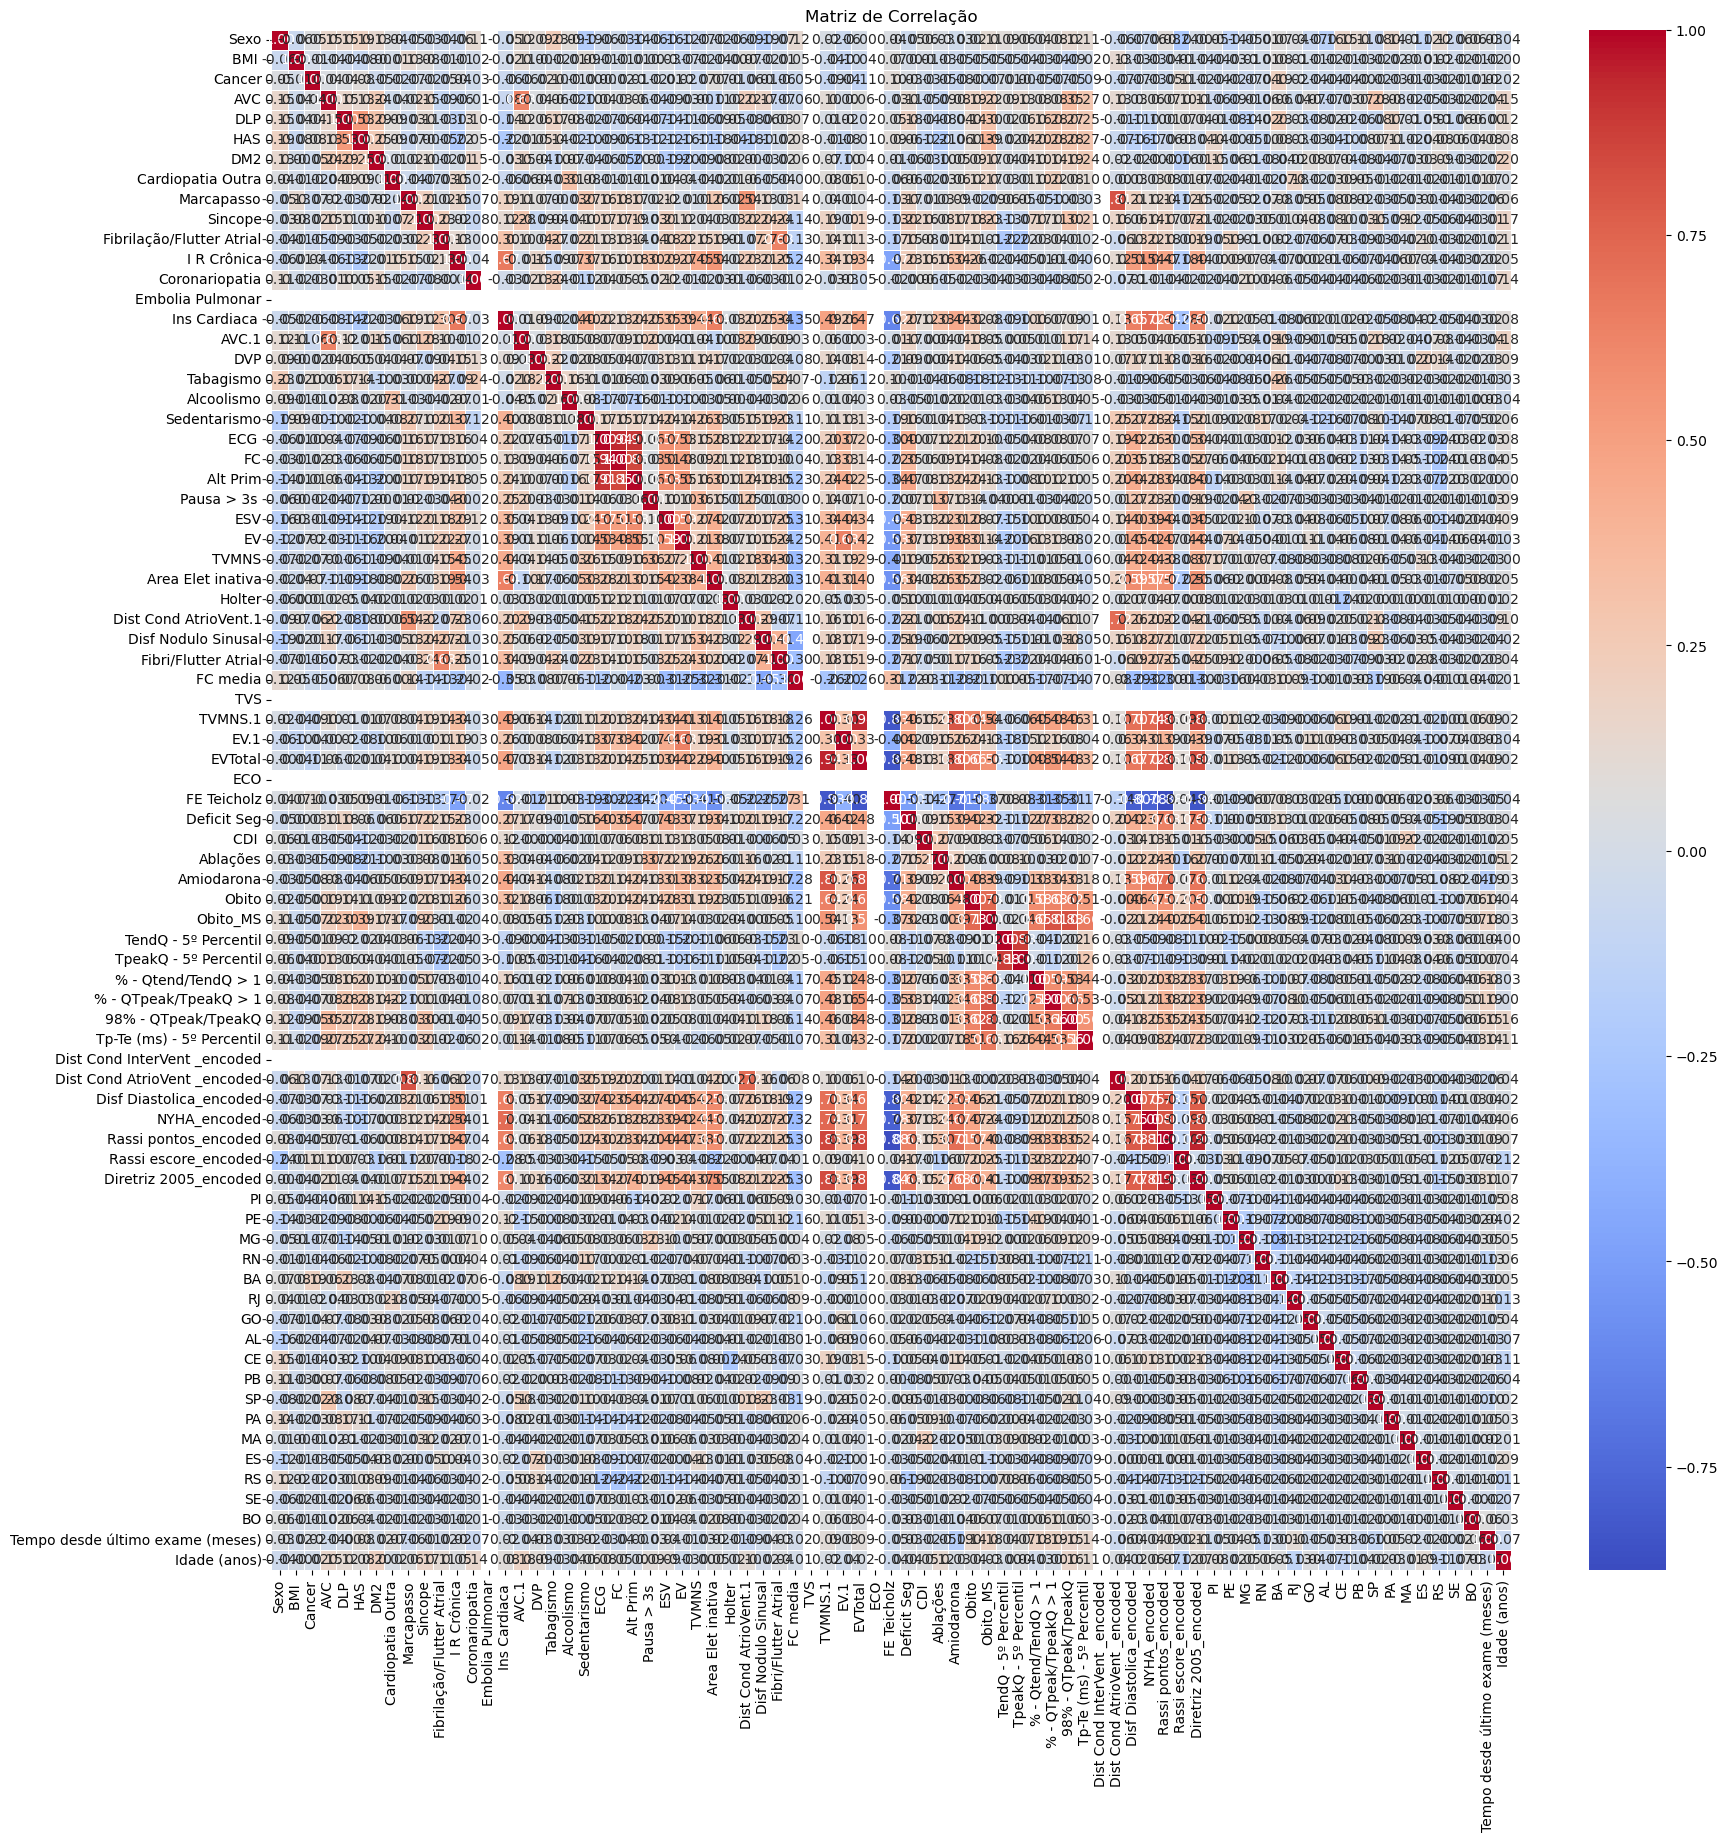

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculando a matriz de correlação
correlation_matrix = tabela.corr()

# Criando um mapa de calor para visualização
plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Matriz de Correlação")
plt.show()


Como existem muitas colunas, vamos filtra-las, para isso vamos estabelecer um limite mínimo de correlação, todas as colunas que tiverem uma relação menor que o limite serão excluídas.

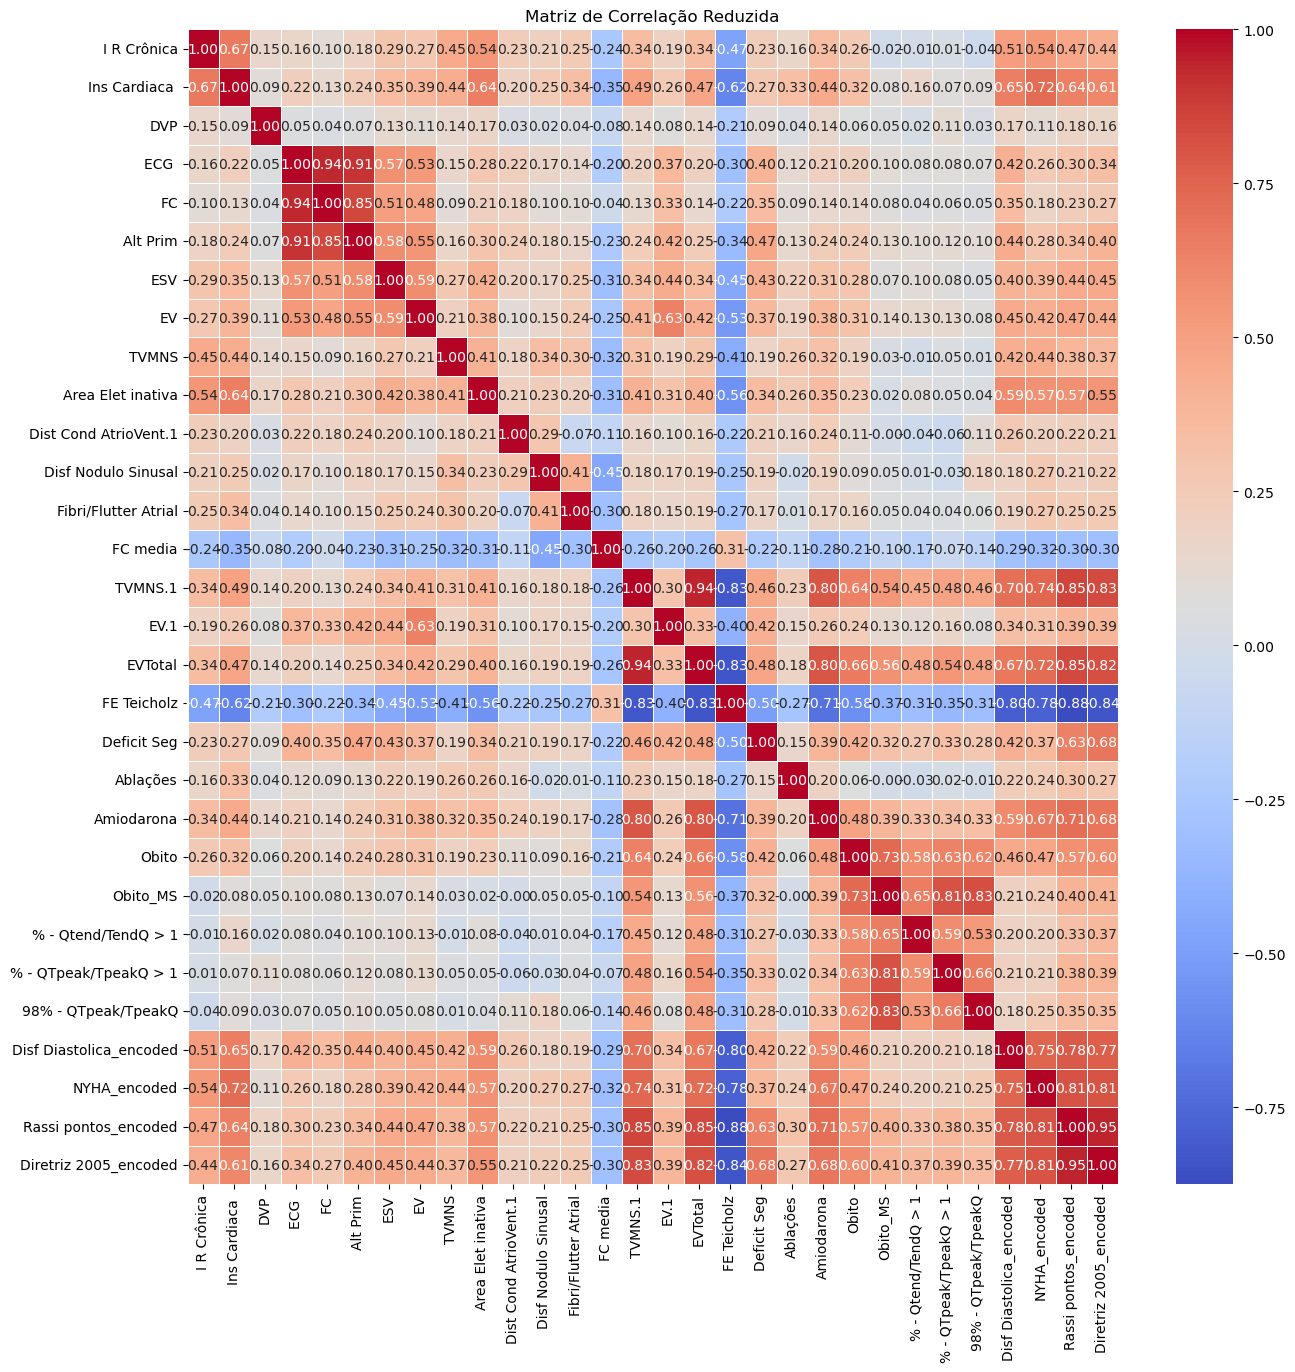

In [24]:
# Definindo um limite de correlação
limite_correlacao = 0.20  # Você pode ajustar esse valor conforme necessário

# Filtrando colunas com correlação significativa
colunas_relevantes = correlation_matrix['FE Teicholz'][abs(correlation_matrix['FE Teicholz']) > limite_correlacao].index

# Gerando a nova matriz de correlação
correlation_matrix_reduzida = tabela[colunas_relevantes].corr()

# Criando um mapa de calor para a nova matriz de correlação
plt.figure(figsize=(15, 15))
sns.heatmap(correlation_matrix_reduzida, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Matriz de Correlação Reduzida")
plt.show()


Realizando a PCA para reduzir a dimensionalidade e visualizar os dados

In [ ]:
print(tabela.columns)

In [ ]:
tabela.info()

Aplicando a PCA Para reduzir a dimensionalidade

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Função para converter valores para float de forma segura
def safe_float_conversion(value):
    if isinstance(value, str):
        try:
            return float(value.replace(',', '.').replace('o', '0'))
        except ValueError:
            return np.nan
    return value

# Aplicar a função de conversão segura para as colunas específicas
colunas_com_virgula = ['TSH', '98% - Qtend/TendQ']
for coluna in colunas_com_virgula:
    if tabela[coluna].dtype == 'object':
        tabela[coluna] = tabela[coluna].apply(safe_float_conversion)

# Agora, aplique a PCA
colunas_numericas = tabela.select_dtypes(include=['float64']).columns
X = tabela[colunas_numericas]

# Tratar valores ausentes, se necessário
X = X.fillna(X.mean())

# Padronizar os dados
scaler = StandardScaler()
X_padronizado = scaler.fit_transform(X)

# Aplicar a PCA
pca = PCA()
X_pca = pca.fit_transform(X_padronizado)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Visualizar a variância explicada acumulada
cumulative_explained_variance = explained_variance_ratio.cumsum()

# Visualizar a variância explicada acumulada em um gráfico
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o')
plt.title('Variância Explicada Acumulada pela PCA')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada Acumulada')
plt.show()


Visualizando a variância de cada componente principal

In [ ]:
# Visualizar a variância explicada de cada componente principal
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.5, align='center')
plt.title('Variância Explicada de Cada Componente Principal')
plt.xlabel('Número do Componente Principal')
plt.ylabel('Variância Explicada')
plt.show()


Plotando o pca com 2 componentes principais

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Criar objeto PCA
pca = PCA()

# Aplicar PCA aos dados padronizados
X_pca = pca.fit_transform(X_padronizado)

# Plotar os dois primeiros componentes principais
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.title('PCA - Dois Primeiros Componentes Principais')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

Plotando o pca com 3 componentes principais

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Criar objeto PCA para 3 componentes principais
pca_3d = PCA(n_components=3)

# Aplicar PCA aos dados padronizados
X_pca_3d = pca_3d.fit_transform(X_padronizado)

# Plotar o gráfico 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c='b', marker='o', alpha=0.5)

ax.set_title('PCA - Três Primeiros Componentes Principais')
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_zlabel('Componente Principal 3')

plt.show()